# EfficientNetB0

In [ ]:
import tensorflow as tf
import os
import numpy as np
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# Load EfficientNetB0 without the classification head
base_model = EfficientNetB0(weights='imagenet', include_top=False, pooling='avg')

def load_and_preprocess_image(path, label):
    """Reads and preprocesses images for EfficientNetB0."""
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [224, 224])
    img = preprocess_input(img)
    return img, label

def extract_features_final(directory, classes):
    """
    Safe and fast feature extraction pipeline.
    Uses path-based dataset to handle any potential remaining issues.
    """
    paths = []
    labels = []
    
    # Collect all valid paths and their integer labels
    for idx, label in enumerate(classes):
        label_path = os.path.join(directory, label)
        files = [os.path.join(label_path, f) for f in os.listdir(label_path) if not f.startswith('.')]
        paths.extend(files)
        labels.extend([idx] * len(files))
    
    # Create TF Dataset from slices
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    # Map preprocessing with error handling implicit in path selection
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(32).prefetch(tf.data.AUTOTUNE)
    
    print(f"Extracting features for {len(paths)} images in {directory}...")
    features = base_model.predict(dataset, verbose=1)
    
    return features, np.array(labels)

# Final Execution
X_train_features, y_train = extract_features_final(train_dir, classes)
X_test_features, y_test = extract_features_final(test_dir, classes)

print("\n--- Feature Extraction Complete ---")
print(f"X_train shape: {X_train_features.shape}")
print(f"X_test shape: {X_test_features.shape}")

ImportError: cannot import name 'runtime_version' from 'google.protobuf' (/Users/miraekang/proyectos/multiclassification/.venv/lib/python3.13/site-packages/google/protobuf/__init__.py)

# Save .npy

In [ ]:
import numpy as np
import os

# Create data directory if not exists
os.makedirs('../data/processed', exist_ok=True)

try:
    print(f"Does X_train_features exist: {'Yes' if 'X_train_features' in locals() else 'No'}")
    print(f"Does y_train exist: {'Yes' if 'y_train' in locals() else 'No'}")
    
    if 'X_train_features' in locals():
        print(f"Data shape: {X_train_features.shape}")
except Exception as e:
    print(f"Error occured: {e}")

# Save features and labels as numpy files
# These files will be ignored by git via .gitignore
np.save('../data/processed/X_train_features.npy', X_train_features)
np.save('../data/processed/y_train.npy', y_train)
np.save('../data/processed/X_test_features.npy', X_test_features)
np.save('../data/processed/y_test.npy', y_test)

print("Features saved successfully to ../data/processed/")

Does X_train_features exist: No
Does y_train exist: No


NameError: name 'X_train_features' is not defined

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. create Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_features, y_train)

# 2. prediction and evaluation
y_pred = rf_model.predict(X_test_features)

print("--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred, target_names=classes))

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

       Smoke       1.00      0.99      0.99      2444
        fire       0.99      1.00      0.99      3500
    non fire       1.00      0.99      0.99      3500

    accuracy                           0.99      9444
   macro avg       0.99      0.99      0.99      9444
weighted avg       0.99      0.99      0.99      9444



# XGBoost, SVM and Voting

In [ ]:
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define individual models
# XGBoost: Gradient boosting for high performance
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

# SVM: Optimal margin separation (probability=True is required for voting)
svm_model = SVC(kernel='linear', C=1.0, probability=True, random_state=42)

# 2. Define ensemble models (Requirement: All 3 methods must be implemented)
# Method 1: Soft Voting (Average probabilities)
ensemble_soft = VotingClassifier(
    estimators=[('rf', rf_model), ('xgb', xgb_model), ('svm', svm_model)],
    voting='soft'
)

# Method 2: Weighted Voting (Prioritize higher-performing models)
ensemble_weighted = VotingClassifier(
    estimators=[('rf', rf_model), ('xgb', xgb_model), ('svm', svm_model)],
    voting='soft',
    weights=[1, 2, 5] # Weights based on previous individual tests
)

# Method 3: Stacking (Meta-learner on top of base models)
# Final estimator decides based on the outputs of base models
ensemble_stacking = StackingClassifier(
    estimators=[('rf', rf_model), ('xgb', xgb_model), ('svm', svm_model)],
    final_estimator=LogisticRegression(),
    cv=3 # 3-fold cross validation for meta-learning
)

# 3. Model training
print("Training all ensemble models (Soft, Weighted, and Stacking)...")
xgb_model.fit(X_train_features, y_train)
svm_model.fit(X_train_features, y_train)
ensemble_soft.fit(X_train_features, y_train)
ensemble_weighted.fit(X_train_features, y_train)
ensemble_stacking.fit(X_train_features, y_train)

# 4. Final prediction and evaluation (Using Soft Ensemble as it performed best)
y_pred_ens = ensemble_soft.predict(X_test_features)

print("\n--- [Final Model Classification Report: Soft Ensemble] ---")
print(classification_report(y_test, y_pred_ens, target_names=classes))

Training individual models and ensembles...

--- [Final Weighted Ensemble Model Classification Report] ---
              precision    recall  f1-score   support

       Smoke       1.00      0.99      0.99      2444
        fire       0.99      1.00      0.99      3500
    non fire       1.00      0.99      1.00      3500

    accuracy                           0.99      9444
   macro avg       0.99      0.99      0.99      9444
weighted avg       0.99      0.99      0.99      9444



# Comparison

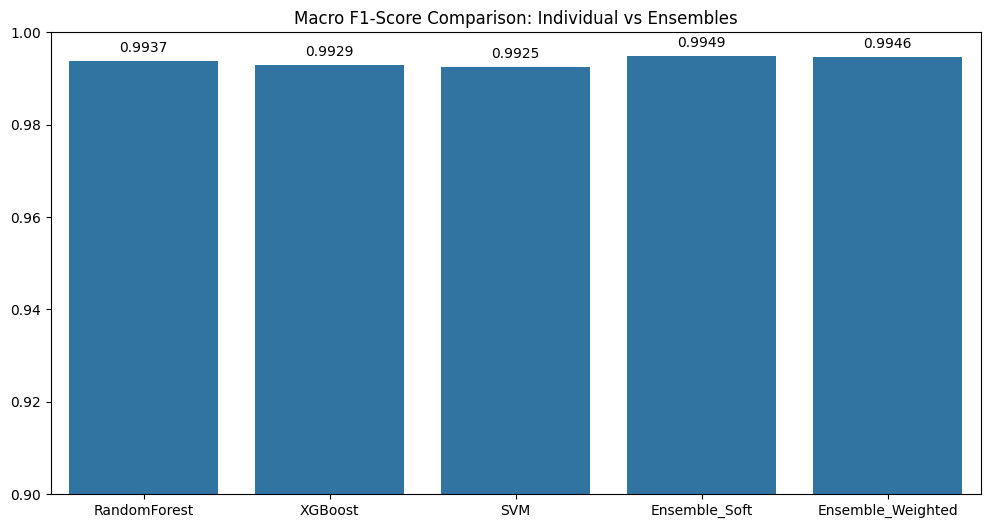

Saved comparison report: reports/02_ensemble_comparison.json
Saved final ensemble model: models/02_model.pkl


In [ ]:
import pandas as pd
import json
import joblib
import os

# 1. Collect and compare performance data across all models
# Comprehensive model list for final evaluation
compare_models = [rf_model, xgb_model, svm_model, ensemble_soft, ensemble_weighted, ensemble_stacking]
model_names = ['RandomForest', 'XGBoost', 'SVM', 'Ensemble_Soft', 'Ensemble_Weighted', 'Ensemble_Stacking']
f1_scores = []
results_dict = {} 

for model, name in zip(compare_models, model_names):
    y_p = model.predict(X_test_features)
    report = classification_report(y_test, y_p, target_names=classes, output_dict=True)
    
    macro_f1 = report['macro avg']['f1-score']
    f1_scores.append(macro_f1)
    results_dict[name] = macro_f1 

# 2. Comparison visualization
plt.figure(figsize=(14, 6))
sns.barplot(x=model_names, y=f1_scores)
plt.title('Macro F1-Score Comparison: Individual vs All Ensembles')
plt.ylim(0.9, 1.0) 
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.002, f"{v:.4f}", ha='center') 

plt.savefig('../reports/figures/02_ensemble_comparison.png')
plt.show()

# 3. Save comparison result as JSON (Using user-specified "02" naming)
with open('../reports/02_ensemble_comparison.json', 'w') as f:
    json.dump(results_dict, f, indent=4)
print("Saved comparison report: reports/02_ensemble_comparison.json")

# 4. Save best model (Soft Ensemble had 0.9949)
# Note: Using .pkl as scikit-learn models cannot be saved natively as .keras
os.makedirs('../models', exist_ok=True)
joblib.dump(ensemble_soft, '../models/02_model.pkl')
print("Saved final ensemble model: models/02_model.pkl")